In [1]:
from tensorflow import keras
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

In [3]:
dataset = 'orig'

In [4]:
test_dir = f'./mobile_net/mel_images/{dataset}/test'

X_test, y_test = load_image_dataset(test_dir, target_size=(224, 224))

In [5]:
modelo = keras.models.load_model(f'./mobile_net/modelos/{dataset}.keras')

In [6]:
modelo.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - auc: 0.7725 - loss: 0.5743 - recall: 0.7488


[0.5742692351341248, 0.7724772691726685, 0.7488151788711548]

In [7]:
preds = modelo.predict(X_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 760ms/step


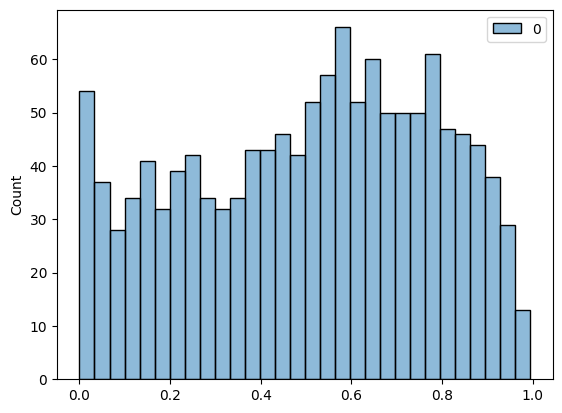

In [8]:
sns.histplot(preds, bins=30);

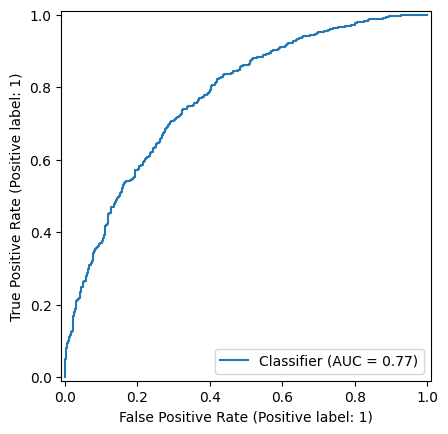

In [9]:
RocCurveDisplay.from_predictions(y_test, preds);

In [10]:
y_pred = (preds >= 0.5).astype(int)

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69       663
           1       0.67      0.75      0.71       633

    accuracy                           0.70      1296
   macro avg       0.70      0.70      0.70      1296
weighted avg       0.70      0.70      0.70      1296



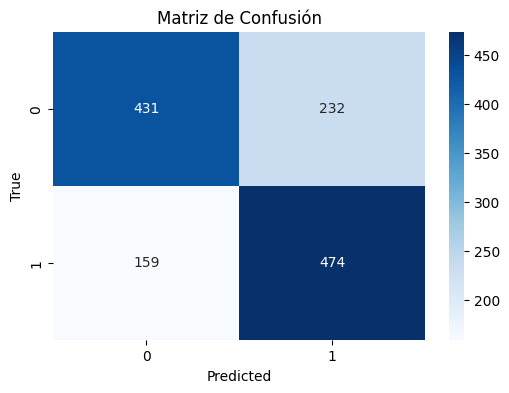

In [12]:
show_confusion_matrix(y_test, y_pred)

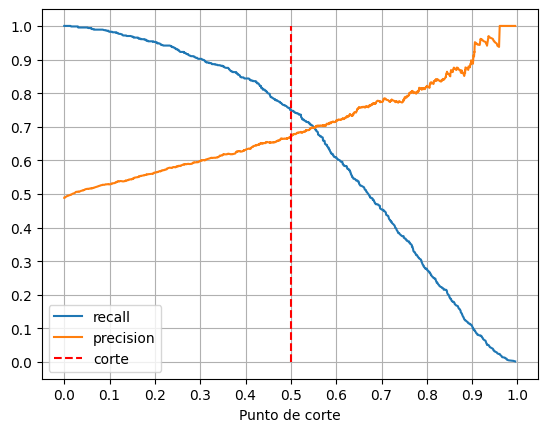

In [13]:
show_precision_recall_curve(y_test, preds, punto_corte=0.5)